**import Data**

In [489]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import f_classif,chi2
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder, OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split

**Read Data**


In [490]:

data_path = os.path.join(os.getcwd(), '..', 'DataSet', 'churn-data.csv')
df = pd.read_csv(data_path)

In [491]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [492]:
# Clean column names
df.columns = df.columns.str.strip().str.replace('_','')

In [493]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [494]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [495]:
df.describe(include='all')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


**EDA**

In [496]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [497]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [498]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [499]:
# target
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [500]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [501]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [502]:
df['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

**Data Viz && Outliers Handling**

**"Univariate Viz"**

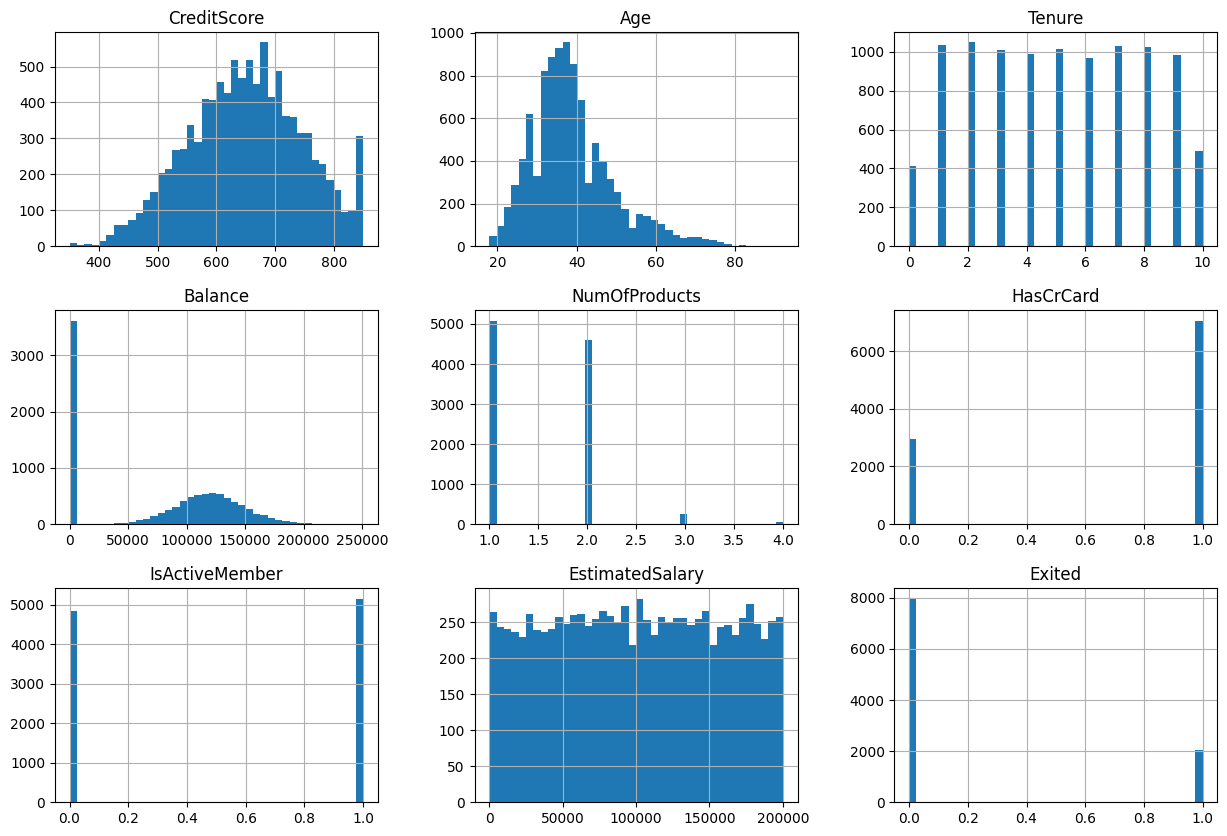

In [503]:
df.hist(bins=40, figsize=(15, 10));

C:\Users\Alwanes\AppData\Local\Temp\ipykernel_3476\1221683305.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='Age', shade=True)


<Axes: xlabel='Age', ylabel='Density'>

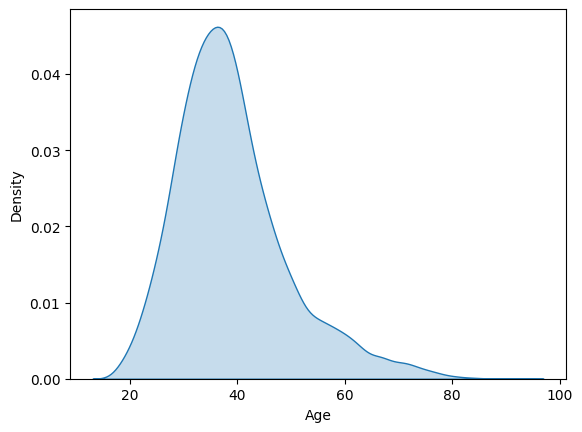

In [504]:
sns.kdeplot(data=df, x='Age', shade=True)

<Axes: xlabel='Age'>

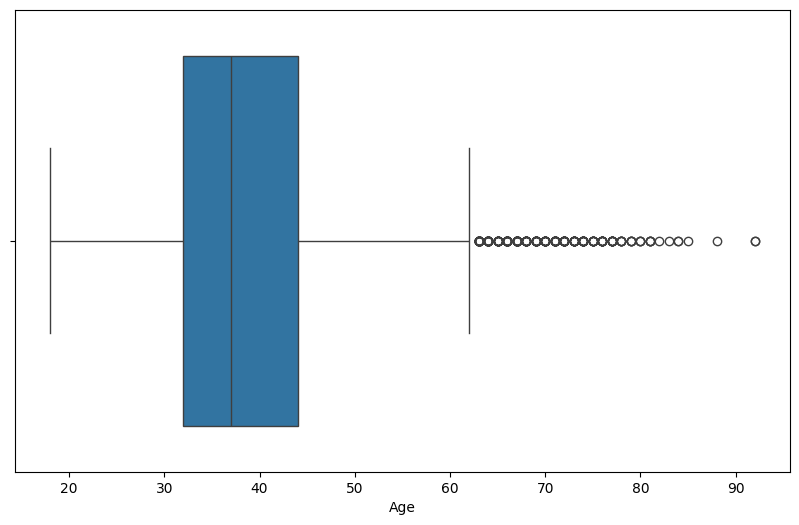

In [505]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Age')

In [506]:
df.drop(index=df[df['Age']>80].index.to_list(),axis=0,inplace=True)

<Axes: xlabel='Age', ylabel='Count'>

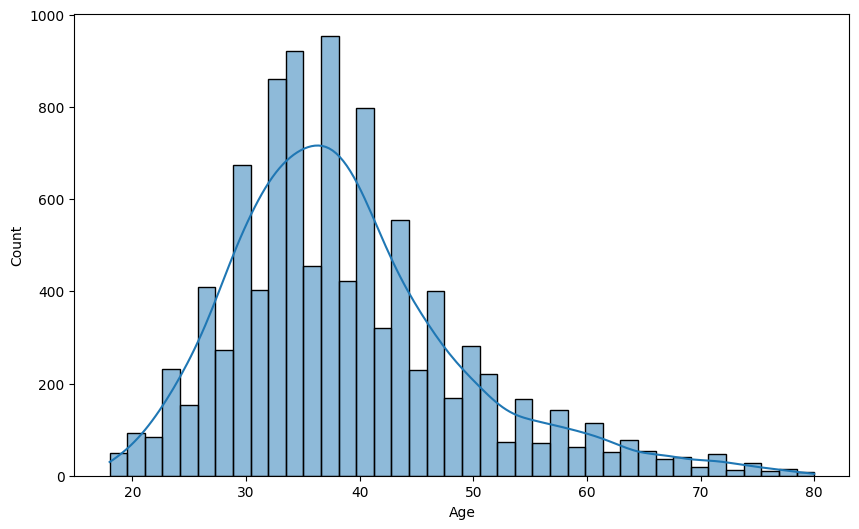

In [507]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', bins=40, kde=True)

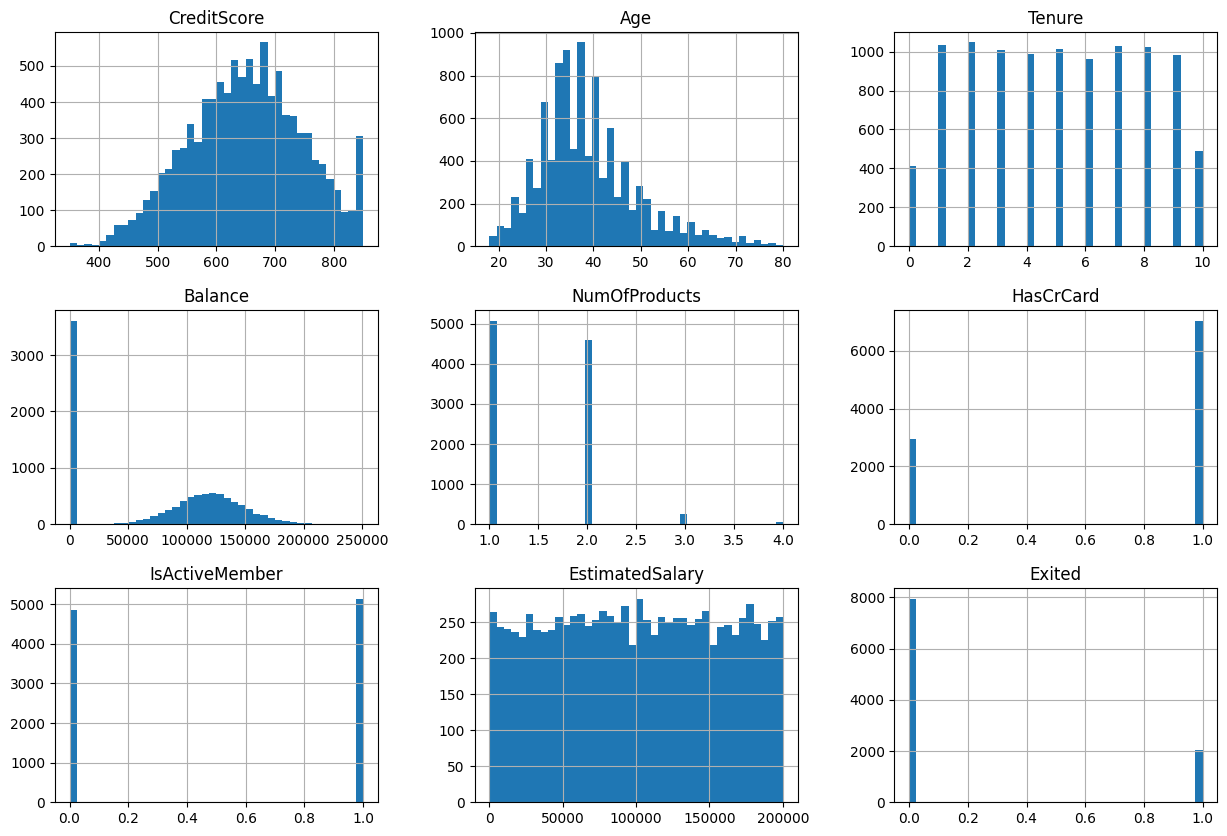

In [508]:
df.hist(bins=40, figsize=(15, 10));

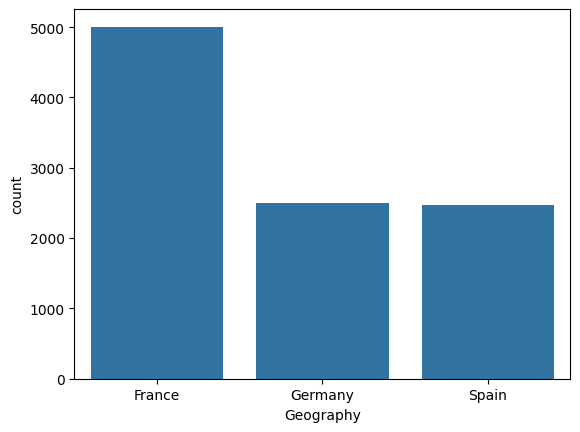

In [509]:
sns.countplot(
    data=df,
    x='Geography',
    order=df['Geography'].value_counts().index.to_list()
);

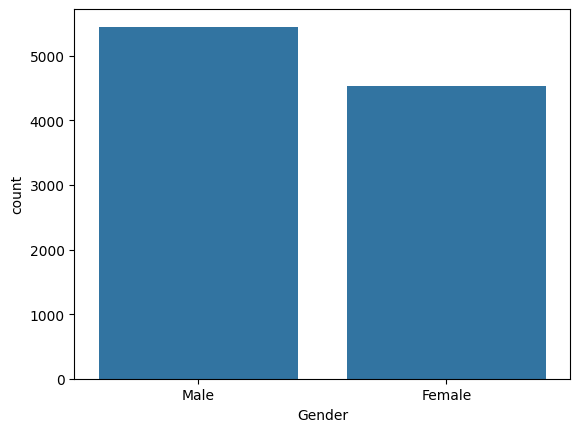

In [510]:
sns.countplot(
    data=df,
    x='Gender',
    order=df['Gender'].value_counts().index.to_list()
);

C:\Users\Alwanes\AppData\Local\Temp\ipykernel_3476\282507437.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['EstimatedSalary'], shade=True)


<Axes: xlabel='EstimatedSalary', ylabel='Density'>

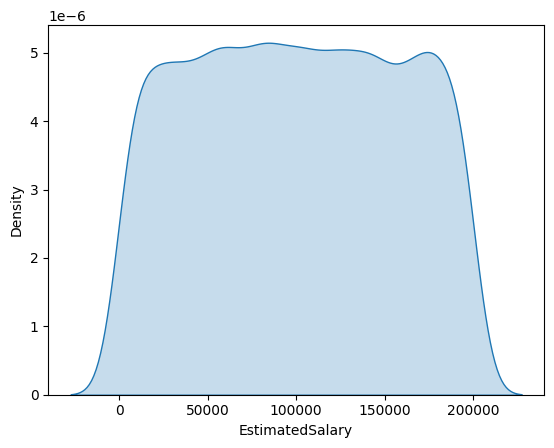

In [511]:
sns.kdeplot(df['EstimatedSalary'], shade=True)

<Axes: ylabel='EstimatedSalary'>

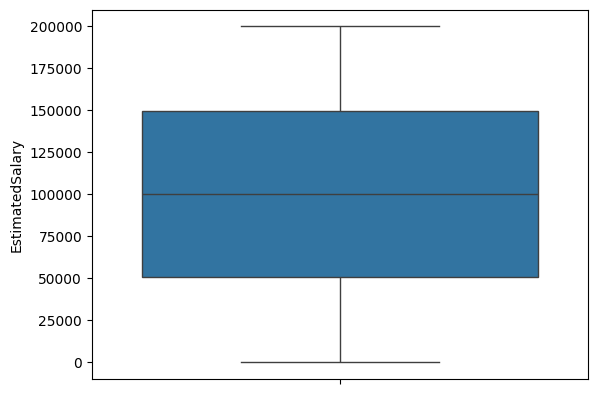

In [512]:
sns.boxplot(y=df['EstimatedSalary'])

<Axes: xlabel='Exited', ylabel='count'>

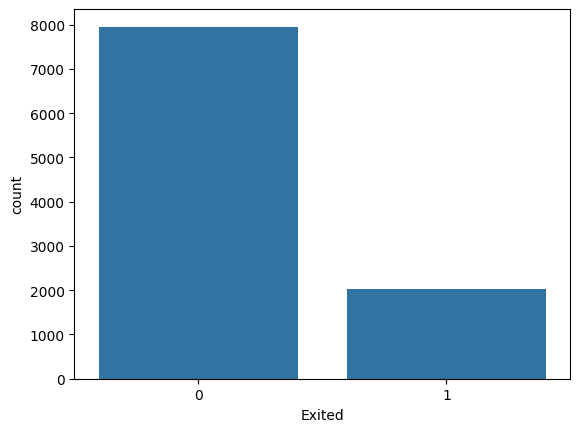

In [513]:
sns.countplot(data=df,x='Exited')

**"Bivaraite Viz"**

In [514]:
df[['Gender','EstimatedSalary']].groupby('Gender')[['EstimatedSalary']].mean()

,EstimatedSalary
Gender,
Female,100575.998277
Male,99671.901194


<Axes: xlabel='Gender', ylabel='EstimatedSalary'>

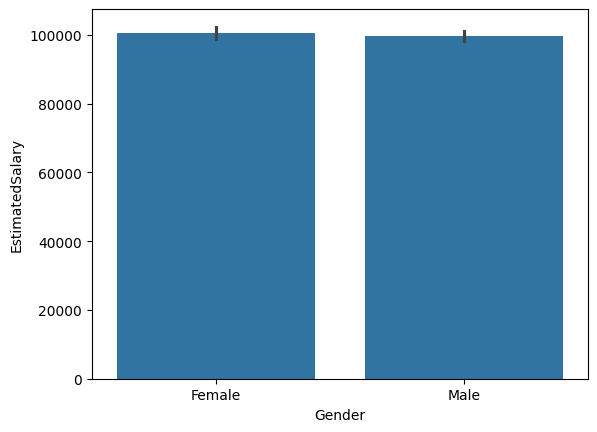

In [515]:
sns.barplot(data=df,y='EstimatedSalary',x='Gender',estimator=np.mean)

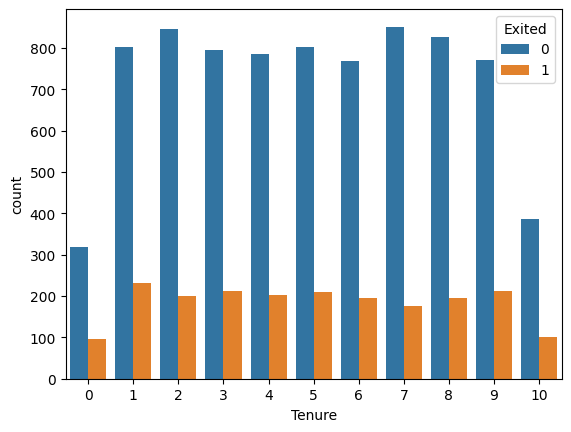

In [516]:
sns.countplot(data=df, x='Tenure', hue='Exited');

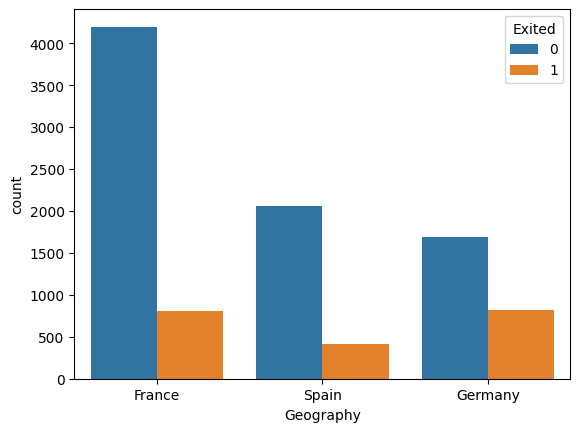

In [517]:
sns.countplot(data=df,x='Geography',hue='Exited');

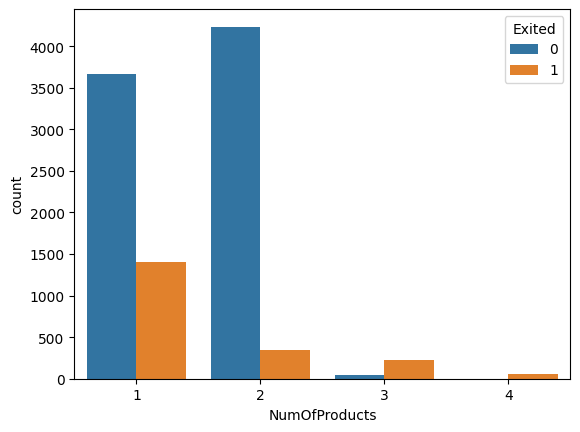

In [518]:
sns.countplot(data=df, x='NumOfProducts', hue='Exited');

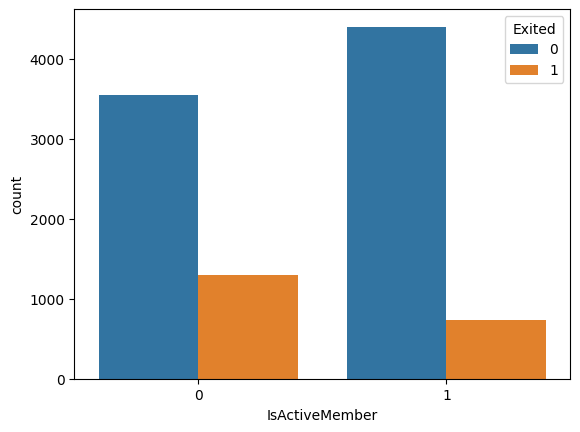

In [519]:
sns.countplot(data=df, x='IsActiveMember', hue='Exited');

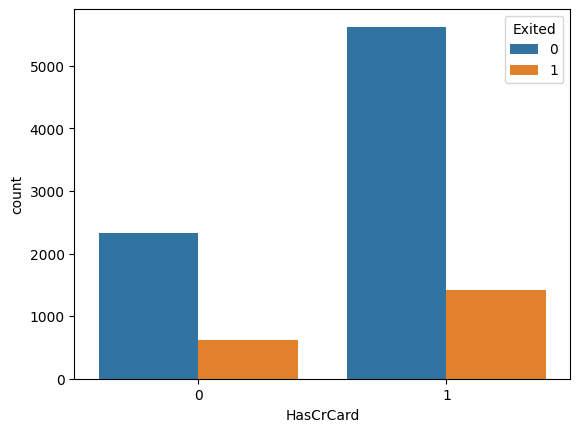

In [520]:
sns.countplot(data=df,x='HasCrCard',hue='Exited');

In [521]:
df[df['HasCrCard']==0].groupby('Exited')['HasCrCard'].count()

Exited
0    2329
1     612
Name: HasCrCard, dtype: int64

In [522]:
((612)/( 2329+612))*100

20.809248554913296

In [523]:
df[df['HasCrCard']==1].groupby('Exited')['HasCrCard'].count()


Exited
0    5623
1    1424
Name: HasCrCard, dtype: int64

In [524]:
(1424/( 1424+5623))*100

20.207180360437064

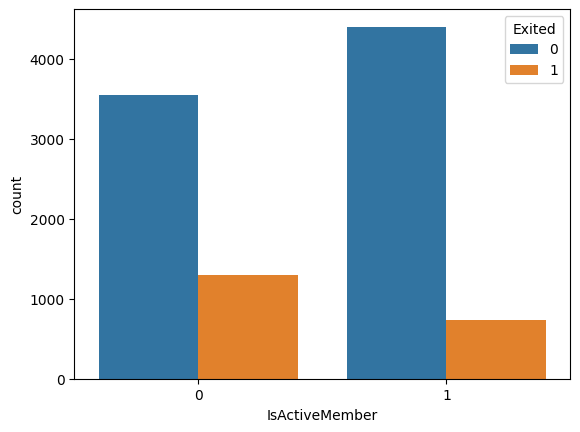

In [525]:
sns.countplot(data=df,x='IsActiveMember',hue='Exited');

In [526]:
df[df['IsActiveMember']==1].groupby('Exited')['IsActiveMember'].count()

Exited
0    4405
1     735
Name: IsActiveMember, dtype: int64

In [527]:
(735/(4405+735))*100

14.299610894941633

In [528]:
(df[df['IsActiveMember']==0].groupby('Exited')['HasCrCard'].count())

Exited
0    3547
1    1301
Name: HasCrCard, dtype: int64

In [529]:
(( 1301)/(3547+1301))*100

26.835808580858085

In [530]:

pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index') * 100

Exited,0,1
IsActiveMember,,
0,73.164191,26.835809
1,85.700389,14.299611


**Split to Train and Test**

In [531]:
# to featueres & target 
X = df.drop(columns=['Exited']) 
y = df['Exited']

# Split to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=45, stratify=y)

# Check shapes
print('X_train.shape \t', X_train.shape)
print('y_train.shape \t', y_train.shape)
print('***'*10)
print('X_test.shape \t', X_test.shape)
print('y_test.shape \t', y_test.shape)

X_train.shape 	 (7990, 10)
y_train.shape 	 (7990,)
******************************
X_test.shape 	 (1998, 10)
y_test.shape 	 (1998,)


**Feature Selectoin & Preprocessing**


In [532]:
X_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2591,634,Germany,Male,38,2,148430.55,1,1,1,56055.72
1980,554,France,Female,30,9,0.00,2,1,1,40320.30
9866,667,France,Male,24,4,0.00,2,0,0,180329.83
7871,676,France,Female,36,3,91711.59,1,1,1,95393.43
5504,786,France,Male,32,2,120452.40,2,0,0,79602.86
...,...,...,...,...,...,...,...,...,...,...
7889,600,Germany,Male,57,9,138456.03,2,1,1,103548.25
7159,525,France,Female,59,6,55328.40,1,1,0,83342.73
5990,573,France,Female,32,9,125321.84,2,1,1,130234.63
6764,570,France,Male,37,6,0.00,1,1,1,187758.50


In [533]:
# slice cols
num_cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']
categ_cols = ['Gender', 'Geography']
ready_cols = list(set(X_train.columns.tolist()) - set(num_cols) - set(categ_cols))

In [534]:
ready_cols

['NumOfProducts', 'Tenure', 'IsActiveMember', 'HasCrCard']

In [535]:
# Numerical cols (num_cols) & Target cols --> ANOVA
_, p_val = f_classif(X=X_train[num_cols], y=y_train)
p_val   # All features p-value less than 0.05 --> Reject H0 --> There is an asscociation

array([1.15359217e-149, 9.12989970e-002, 3.56368021e-025, 6.16127881e-001])

In [536]:
# Categorical cols (categ_cols) & Target cols --> chi2
_, p_val = chi2(X=OrdinalEncoder().fit_transform(X_train[categ_cols]), y=y_train)
p_val  # All features p-value less than 0.05 --> Reject H0 --> There is an asscociation

array([5.13986341e-10, 1.56448286e-03])

In [537]:

# Ready cols (ready_cols) & Target cols --> chi2
_, p_val = chi2(X=X_train[ready_cols], y=y_train)
p_val  # All features p-value less than 0.05 --> Reject H0 --> There is an asscociation

array([6.55133468e-02, 6.36015039e-02, 7.15759804e-22, 6.69284702e-01])

In [538]:
corr_with_target = df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)
print(corr_with_target)

Exited             1.000000
Age                0.290329
Balance            0.118396
EstimatedSalary    0.011794
HasCrCard         -0.006812
Tenure            -0.014169
CreditScore       -0.026316
NumOfProducts     -0.047575
IsActiveMember    -0.155526
Name: Exited, dtype: float64


In [539]:

# Pipeline

# Numerical: num_cols --> Imputing using median, and standardscaler
# Categorical: categ_cols ---> Imputing using mode, and OHE
# Ready_cols ---> Imputing mode


# For Numerical
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For Categorical
categ_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'))
])

# For Ready cols
ready_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

# Combine all
preprocessor = ColumnTransformer(transformers=[
    ('numerical', num_pipeline, num_cols),
    ('categorical', categ_pipeline, categ_cols),
    ('ready', ready_pipeline, ready_cols)
])

#Apply to train and test
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [540]:
# Check train
X_train_final.shape, y_train.shape

((7990, 11), (7990,))

In [541]:
# Check test
X_test_final.shape, y_test.shape

((1998, 11), (1998,))

* `Deal with imbalanced dataset`

In [542]:
# 1. prepare class_weights for solving imbalance dataset
vals_count = 1 - (np.bincount(y_train) / len(y_train))
vals_count = vals_count / sum(vals_count)

dict_weights = {}
for i in range(2):  # 2 classes (0, 1)
    dict_weights[i] = vals_count[i]

# to model
dict_weights

{0: np.float64(0.20387984981226537), 1: np.float64(0.7961201501877346)}

*`2-Using Smote for over sampling`

In [543]:
over = SMOTE(k_neighbors=5, sampling_strategy=0.7, random_state=45)
X_train_final_resampled, y_train_resampled = over.fit_resample(X_train_final, y_train)

In [544]:
# Create fodler for the models
MODELS_FOLDER_PATH = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)

In [545]:
# dump the preprocessor
joblib.dump(preprocessor, os.path.join(MODELS_FOLDER_PATH, 'preprocessor.pkl'))

['d:\\Churn Modelling\\Notebooks\\..\\models\\preprocessor.pkl']

* `Building Models`
> Let's consider the evaluation metric to be f1_score

1. Using Logistic Regression

In [546]:
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final, y_train)

# Predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)


print(f'The f1_score using Logistic model for Training Dataset is {score_train_log*100:.3f}')
print(f'The f1_score using Logistic model for Testing Dataset is {score_test_log*100:.3f}')

The f1_score using Logistic model for Training Dataset is 30.888
The f1_score using Logistic model for Testing Dataset is 37.500


In [547]:
# 2. Using logisit -- with considering the imabalancing data using class_weights
log_clf = LogisticRegression(C=1.5, class_weight=dict_weights)
log_clf.fit(X_train_final, y_train)

# Predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using Logistic model for Training Dataset with class_weigths is {score_train_log*100:.3f}')
print(f'The f1_score using Logistic model for Testing Dataset with class_weigths is {score_test_log*100:.3f}')

The f1_score using Logistic model for Training Dataset with class_weigths is 49.814
The f1_score using Logistic model for Testing Dataset with class_weigths is 49.915


In [548]:
# 3. Using logisit -- with considering the imabalancing data using oversampled data (SMOTE)
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using Logistic model for Training Dataset with SMOTE is {score_train_log*100:.3f}')
print(f'The f1_score using Logistic model for Testing Dataset with SMOTE is {score_test_log*100:.3f}')

The f1_score using Logistic model for Training Dataset with SMOTE is 49.743
The f1_score using Logistic model for Testing Dataset with SMOTE is 50.420


<Axes: >

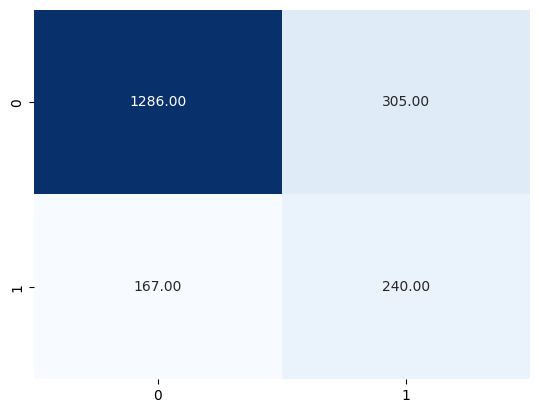

In [549]:
sns.heatmap(confusion_matrix(y_true=y_test, y_pred=y_pred_test_log), cmap='Blues', cbar=False, annot=True, fmt='.2f')

In [550]:
# clf report
print(classification_report(y_test, y_pred_test_log))

              precision    recall  f1-score   support

           0       0.89      0.81      0.84      1591
           1       0.44      0.59      0.50       407

    accuracy                           0.76      1998
   macro avg       0.66      0.70      0.67      1998
weighted avg       0.79      0.76      0.78      1998



* `RandomForest`

In [551]:
# Using RF -- With class_weights
forst_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45, class_weight=dict_weights)
forst_clf.fit(X_train_final, y_train)

# Predict and evaluate
y_pred_train_forest = forst_clf.predict(X_train_final)
y_pred_test_foerst = forst_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_foerst)

print(f'The f1_score using RF model for Training Dataset with class_weights is {score_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset with class_weights is {score_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset with class_weights is 59.895
The f1_score using RF model for Testing Dataset with class_weights is 57.879


In [552]:
# Using RF -- With SMOTE
forst_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45)
forst_clf.fit(X_train_final_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_forest = forst_clf.predict(X_train_final)
y_pred_test_foerst = forst_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_foerst)

print(f'The f1_score using RF model for Training Dataset with SMOTE is {score_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset with SMOTE is {score_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset with SMOTE is 61.962
The f1_score using RF model for Testing Dataset with SMOTE is 59.269


* `RF-Tuning`

In [553]:
forest_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45, class_weight=dict_weights)

# Your space to search
params_best_grid = {
            'n_estimators': np.arange(50, 400, 50),
            'max_depth': np.arange(6, 10, 2)
}

grid_search_forest = GridSearchCV(estimator=forest_base_clf, param_grid=params_best_grid, 
                                  cv=5, n_jobs=-1, verbose=4, scoring='f1')
grid_search_forest.fit(X_train_final, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=45)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([6, 8]), 'n_estimators': array([ 50, 1...50, 300, 350])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [554]:
# The best score according to your scoring & The best combination of what you search in
grid_search_forest.best_score_, grid_search_forest.best_params_

(np.float64(0.6160225050368933),
 {'max_depth': np.int64(8), 'n_estimators': np.int64(50)})

In [555]:
# The forest after tuning
forest_tuned = grid_search_forest.best_estimator_

# Predict and evaluate
y_pred_train_forest_tuned = forest_tuned.predict(X_train_final)
y_pred_test_forest_tuned = forest_tuned.predict(X_test_final)

# Using f1_score
score_train_forest_tuned = f1_score(y_train, y_pred_train_forest_tuned)
score_test_forest_tuned = f1_score(y_test, y_pred_test_forest_tuned)

print(f'The f1_score using tuned RF model for Training Dataset with class_weigths is {score_train_forest_tuned*100:.3f}')
print(f'The f1_score using tuned RF model for Testing Dataset with class_weigths is {score_test_forest_tuned*100:.3f}')

The f1_score using tuned RF model for Training Dataset with class_weigths is 68.011
The f1_score using tuned RF model for Testing Dataset with class_weigths is 62.366


In [556]:
# Downlaod it if you are satisifed with the above model
joblib.dump(forest_tuned, os.path.join(MODELS_FOLDER_PATH, 'forest_tuned.pkl'))

['d:\\Churn Modelling\\Notebooks\\..\\models\\forest_tuned.pkl']

In [557]:
forest_tuned.feature_importances_

array([0.37028144, 0.05207   , 0.09114963, 0.05113677, 0.02351618,
       0.05211907, 0.00685798, 0.25149133, 0.02948717, 0.06535186,
       0.00653857])

In [558]:
# Get the features out from the preprocessor
features_after = [name.split('__')[1] for name in preprocessor.get_feature_names_out()]
features_after

['Age',
 'CreditScore',
 'Balance',
 'EstimatedSalary',
 'Gender_Male',
 'Geography_Germany',
 'Geography_Spain',
 'NumOfProducts',
 'Tenure',
 'IsActiveMember',
 'HasCrCard']

In [559]:
# Feature Importance from RF
forest_tuned_importance = pd.DataFrame({'feature': features_after, 
                              'importance': forest_tuned.feature_importances_}).sort_values('importance', ascending=False)
forest_tuned_importance

,feature,importance
0,Age,0.370281
7,NumOfProducts,0.251491
2,Balance,0.091150
9,IsActiveMember,0.065352
5,Geography_Germany,0.052119
1,CreditScore,0.052070
3,EstimatedSalary,0.051137
8,Tenure,0.029487
4,Gender_Male,0.023516
6,Geography_Spain,0.006858


**XGBOOST**

In [560]:
xgb_base_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, 
                                 learning_rate=0.1, n_estimators=150, random_state=42)
xgb_base_model.fit(X_train_final, y_train)

# Predict and evaluate
y_pred_train_xgb = xgb_base_model.predict(X_train_final)
y_pred_test_xgb = xgb_base_model.predict(X_test_final)

# Using f1_score
score_train_xgb = f1_score(y_train, y_pred_train_xgb)
score_test_xgb = f1_score(y_test, y_pred_test_xgb)

print(f'The f1_score using XGBoost model for Training Dataset with scale is {score_train_xgb*100:.3f}')
print(f'The f1_score using XGBoost model for Testing Dataset with scale is {score_test_xgb*100:.3f}')

The f1_score using XGBoost model for Training Dataset with scale is 70.294
The f1_score using XGBoost model for Testing Dataset with scale is 59.549


In [561]:
# scale
scale = (y_train == 0).sum() / (y_train == 1).sum()


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = class_weights / np.sum(class_weights)
weight_dict = dict(zip(np.unique(y_train), class_weights))

sample_weights = np.array([weight_dict[y] for y in y_train])

In [ ]:
# Dump model
joblib.dump(xgb_tuned, os.path.join(MODELS_FOLDER_PATH, 'xgb-tuned.pkl'))

['d:\\Churn Modelling\\Notebooks\\..\\models\\xgb-tuned.pkl']

In [562]:
xgb_base_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, reg_lambda=5,
                                 learning_rate=0.1, n_estimators=150, random_state=4)

In [563]:
# Hyperparameter tuning with class weights
param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'n_estimators': [100, 200, 300, 400],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
}


random_search_xgb = RandomizedSearchCV(estimator=xgb_base_model, param_distributions=param_dist, 
                                       cv=5, n_jobs=-1, n_iter=25, scoring='f1', random_state=48)
random_search_xgb.fit(X_train_final, y_train, sample_weight=sample_weights)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [564]:
# The xgb after tuning
xgb_tuned = random_search_xgb.best_estimator_   ## The best model contains the best params you search in

# Predict and evaluate
y_pred_train_xgboost_tuned = xgb_tuned.predict(X_train_final)
y_pred_test_xgboost_tuned = xgb_tuned.predict(X_test_final)

# Using f1_score
score_train_xgb_tuned = f1_score(y_train, y_pred_train_xgboost_tuned)
score_test_xgb_tuned = f1_score(y_test, y_pred_test_xgboost_tuned)

print(f'The f1_score using tuned XGBoost model for Training Dataset with scale is {score_train_xgb_tuned*100:.3f}')
print(f'The f1_score using tuned XGBoost model for Testing Dataset with scale is {score_test_xgb_tuned*100:.3f}')

The f1_score using tuned XGBoost model for Training Dataset with scale is 62.413
The f1_score using tuned XGBoost model for Testing Dataset with scale is 61.181


In [565]:
# Dump model
joblib.dump(xgb_tuned, os.path.join(MODELS_FOLDER_PATH, 'xgb-tuned.pkl'))

['d:\\Churn Modelling\\Notebooks\\..\\models\\xgb-tuned.pkl']